<a href="https://colab.research.google.com/github/padmacharan-123/APPLIED-AI-REC-1/blob/main/AAI_EXP11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
!pip install ultralytics roboflow opencv-python

In [44]:
from ultralytics import YOLO
import cv2
import os
import time
import numpy as np
from google.colab import files

In [57]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AG6HHokZim0It7Z4NFMZ")
project = rf.workspace("padmacharans-workspace").project("monitor-keyboard-mouse-bvmqe")
version = project.version(1)
dataset = version.download("yolov8")


Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 27% ━━━───────── 10900/40671 84.0files/s 35.8s<5:54Requirement already satisfied: roboflow in /usr/local/lib/python3.12/dist-packages (1.2.16)
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 27% ━━━───────── 10902/40671 62.1files/s 36.0s<7:60Requirement already satisfied: urllib3>=1.26.6 in /usr/local/lib/python3.12/dist-packages (from roboflow) (2.5.0)
loading Roboflow workspace...
loading Roboflow project...
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 29% ━━━╸──────── 11964/40671 69.8files/s 42.0s<6:51

In [58]:
print(os.listdir(dataset.location))
print(os.listdir(dataset.location + "/train/images")[:5])

['train', 'data.yaml', 'README.roboflow.txt', 'test', 'README.dataset.txt', 'valid']
['WIN_20230110_10_28_56_Pro_jpg.rf.6301c2588753451533d349ab87c882f6.jpg', '12e6de4a-0b78-4843-8ab1-1bb95283d909_jpg.rf.38a93156f81796b86555d67f94066288.jpg', 'WIN_20230110_10_28_12_Pro_jpg.rf.d47c28813ecaf7c878acdd0e344ccb1e.jpg', '5e8309a5b92c2e67058b4568_1585650801_jpg.rf.2d6d5a4d9f0b05bd8a2ca364940df43b.jpg', 'images119_jpg.rf.bcecb75225a5c35819485202b7c1f7c0.jpg']
Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 33% ━━━╸──────── 13550/40671 12.3files/s 47.4s<36:52

In [59]:
def resize_images(folder):
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.resize(img, (640, 640))
        cv2.imwrite(path, img)

resize_images(dataset.location + "/train/images")
resize_images(dataset.location + "/valid/images")

Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 39% ━━━━╸─────── 15908/40671 349.6files/s 58.2s<1:11

In [60]:
def denoise_images(folder):
    for img_name in os.listdir(folder):
        path = os.path.join(folder, img_name)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.GaussianBlur(img, (5,5), 0)
        cv2.imwrite(path, img)

# Uncomment if needed
# denoise_images(dataset.location + "/train/images")

In [61]:
model = YOLO("yolov8n.pt")  # pretrained model

Unzipping /content/datasets/coco/images/test2017.zip to /content/datasets/coco/images/test2017...: 45% ━━━━━─────── 18193/40671 149.3files/s 1:04<2:31

In [62]:
model.train(
    data=dataset.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    augment=True
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/monitor,keyboard,mouse-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b0b50fab3e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [63]:
metrics = model.val()

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1327.3±382.5 MB/s, size: 77.8 KB)
val: Scanning /content/monitor,keyboard,mouse-1/valid/labels.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 15.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.5it/s 2.7s
              keyboard          8          8      0.959      0.875      0.982      0.709
               monitor         41         43      0.975      0.908      0.969      0.731
                 mouse         11         12       0.92      0.959      0.989      0.711
Speed: 10.9ms preprocess, 4.9ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /content/runs/detect/val5
mAP50-95: 0.7170858393209616
Precision: 0.95127614869036
Recall: 0.9141171483559134


In [64]:
def measure_latency(image_path):
    start = time.time()
    results = model(image_path)
    end = time.time()

    inference_time = end - start
    fps = 1 / inference_time

    return results, inference_time, fps

In [65]:
uploaded = files.upload()


image 1/1 /content/how-to-connect-keyboard-to-monitor-1691909478 (3).jpg: 480x640 1 keyboard, 1 monitor, 7.7ms
Speed: 3.8ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
Inference Time: 0.07700324058532715
FPS: 12.986466444771267
Total Objects Count: 2

--- Object Measurements ---
Object Size (cm): 1.5227927202754015
Object Size (cm): 2.5

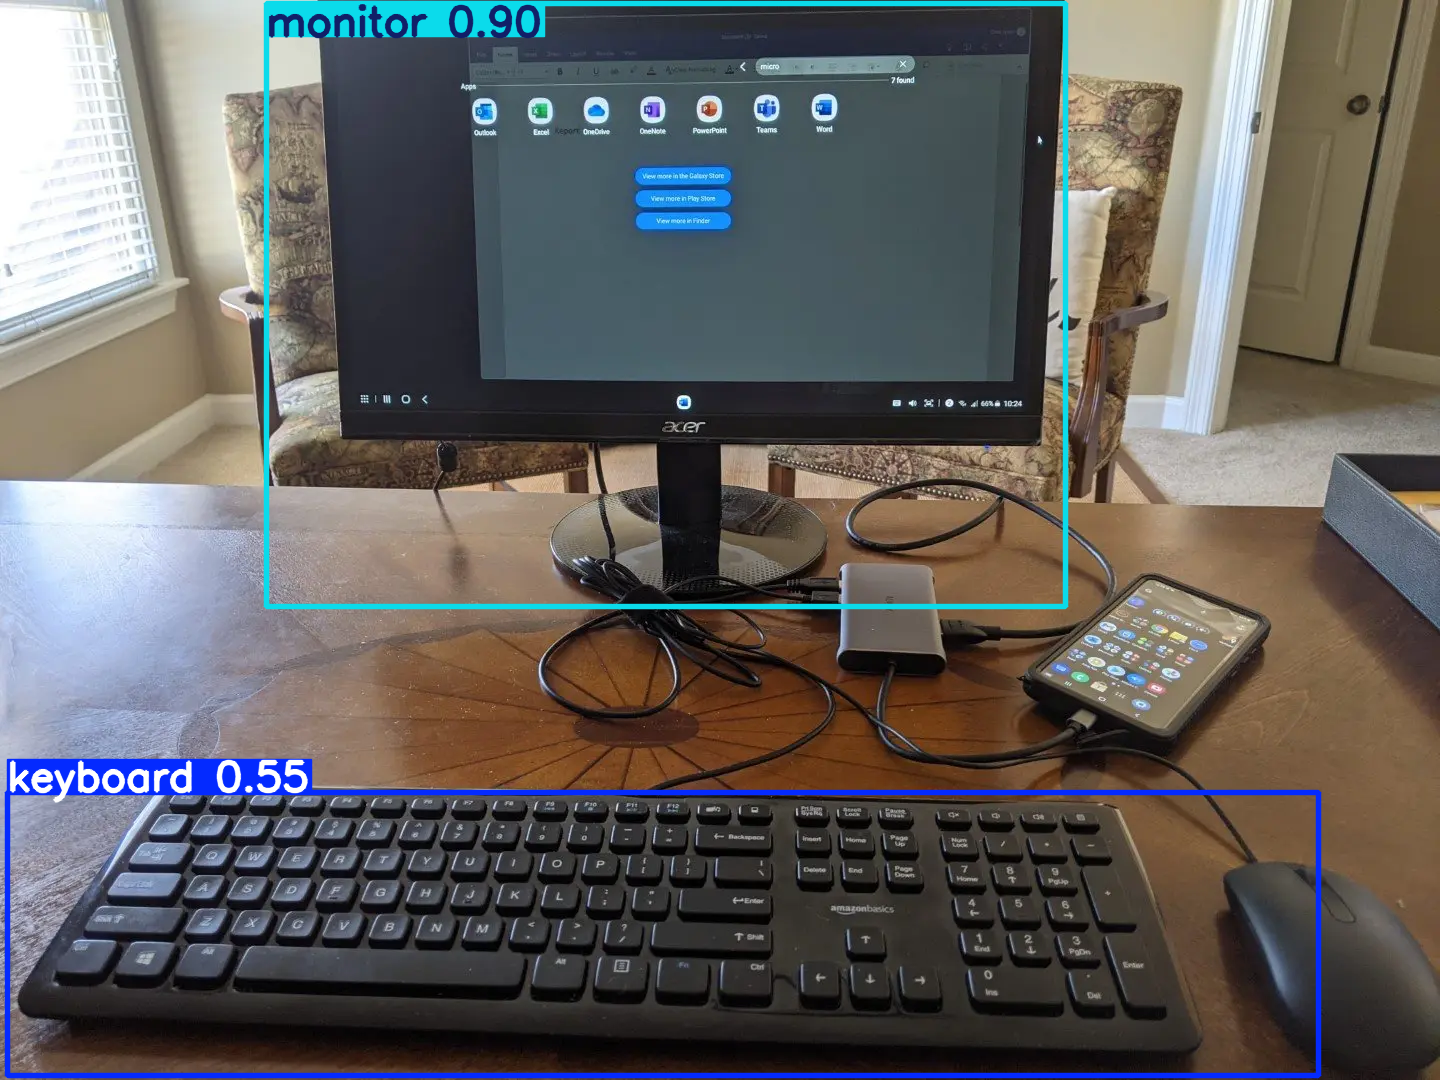

In [66]:
# Define reference object (example: coin)
REFERENCE_CLASS = 0        # change based on your dataset class id
REFERENCE_SIZE_CM = 2.5    # real size of coin

for img_path in uploaded.keys():

    results, inference_time, fps = measure_latency(img_path)

    print("Inference Time:", inference_time)
    print("FPS:", fps)

    count = 0
    reference_pixels = None

    for r in results:
        for box_data in r.boxes:
            conf = float(box_data.conf[0])

            if conf < 0.5:
                continue

            count += 1 # Increment count for each valid detection

            cls = int(box_data.cls[0])
            x1, y1, x2, y2 = box_data.xyxy[0]

            width = float(x2 - x1)
            height = float(y2 - y1)

            # Detect reference object
            if cls == REFERENCE_CLASS:
                reference_pixels = width

    print("Total Objects Count:", count)

    # Measurement calculation
    if reference_pixels is not None:
        print("\n--- Object Measurements ---")

        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = box.xyxy[0]

                obj_width = float(x2 - x1)

                real_size = (obj_width / reference_pixels) * REFERENCE_SIZE_CM

                print("Object Size (cm):", real_size)

    else:
        print("⚠️ Reference object not detected!")

    results[0].show()